# التحليل الثانوي للبيانات

In [92]:
import numpy as np  # مكتبة التحليل الأولي لعمليات الرياضيات والإحصاء
import pandas as pd  # مكتبة التحليل الثانوي لتحليل ومعالجة البيانات
import matplotlib.pyplot as plt  # مكتبة التحليل الثانوي لإنشاء الرسوم البيانية
import seaborn as sns  # مكتبة التحليل الثانوي لإنشاء الرسوم البيانية المتقدمة
import sklearn#للتقسيم
import os
import arabic_reshaper
from bidi.algorithm import get_display
import numexpr as ne
from bidi import algorithm as bidialg
import unittest
import pandas as pd
import matplotlib.pyplot as plt
from googletrans import Translator
from bidi import algorithm as bidialg
import arabic_reshaper
from bidi.algorithm import get_display
import statsmodels
import tensorflow as tf
import torch
from scipy.stats import chi2_contingency
import nltk#لتعلم النصوص ولن احتاجها هنا
from tabulate import tabulate
from textblob import TextBlob#لتعلم النصوص ولن احتاجها هنا
import dask.dataframe as dd
import geopandas  #للخرائط
import base64
import base64

In [95]:

# تحميل ملف CSV
data = pd.read_csv('KidneyPatientsGHadeer.csv', encoding='utf-8')


# التحليل الإحصائي

# تحليل الترددات باستخدام Pandas حسب تكرار البيانات داخل كل عمود

In [3]:

# حساب الترددات لمتغير الجنس
Gender_freq = data['Gender'].value_counts()

# حساب الترددات لمتغير العمر
TheAge_freq = pd.cut(data['TheAge'], bins=[0, 20, 40, 60, 80, 100]).value_counts()

# حساب الترددات لمتغير المديرية
Directorate_freq = data['Directorate'].value_counts()
# حساب الترددات لمتغير المدينة
Governorate_freq = data['Governorate'].value_counts()

# حساب الترددات لمتغير فئة الدم
BloodType_freq = data['BloodType'].value_counts()

# حساب الترددات لمتغير فئة نوع الفيروس
VirusType_freq = data['VirusType'].value_counts()

# حساب الترددات لمتغير تاريخ اول غسلة 
TheDateTheFirstWash_freq = data['TheDateTheFirstWash'].value_counts()

# حساب الترددات لمتغير السنة المرضية
Sickyear_freq = data['Sickyear'].value_counts()

# حساب الترددات لمتغيرتاريخ الوفاة
DateOfDeath_freq = data['DateOfDeath'].value_counts()

# حساب الترددات لمتغيرالنازحين
nazeh_freq = data['nazeh'].value_counts()

# طباعة الترددات

print('\nGender Frequencies:')
print(Gender_freq)


print('\nTheAge Frequencies:')
print(TheAge_freq)


print('\nDirectorate Frequencies:')
print(Directorate_freq)

print('\nGovernorate Frequencies:')
print(Governorate_freq)

print('\nBloodType Frequencies:')
print(BloodType_freq)


print('\nVirusType Frequencies:')
print(VirusType_freq)

print('\nTheDateTheFirstWash Frequencies:')
print(TheDateTheFirstWash_freq)


print('\nSickyear Frequencies:')
print(Sickyear_freq)


print('\nDateOfDeath Frequencies:')
print(DateOfDeath_freq)


print('\nnazeh Frequencies:')
print(nazeh_freq)


Gender Frequencies:
Gender
ذكر     2372
أنثى    1456
Name: count, dtype: int64

TheAge Frequencies:
TheAge
(40, 60]     1767
(20, 40]     1235
(60, 80]      588
(0, 20]       201
(80, 100]      35
Name: count, dtype: int64

Directorate Frequencies:
Directorate
بعدان         226
تعز           222
العدين        222
السياني       187
إب            144
             ... 
الحول           1
الريف           1
لبيس            1
حسن             1
نجد الحداد      1
Name: count, Length: 222, dtype: int64

Governorate Frequencies:
Governorate
إب         2395
تعز        1056
الحديدة     190
الضالع      103
ذمار         44
لحج          21
المحويت       6
عدن           5
حجة           4
البيضاء       2
أبين          1
عمران         1
Name: count, dtype: int64

BloodType Frequencies:
BloodType
o+     2494
a+      874
o-      136
b+      135
ab+     131
a-       45
b-       13
Name: count, dtype: int64

VirusType Frequencies:
VirusType
neg    3212
c       456
b       159
c+b       1
Name: count, dtype:

# التحليل الوصفي

In [38]:

# إنشاء إطار بيانات DataFrame
df = pd.DataFrame(data)

# عرض بعض المعلومات الأولية عن البيانات
print(df.head())

# وصف البيانات الإحصائي
print(df.describe())

# عدد القيم المفقودة في كل عمودة
print(df.isnull().sum())


  Gender  TheAge Directorate Governorate BloodType VirusType   
0    ذكر      50      العدين          إب        a+       neg  \
1    ذكر      42       بعدان          إب        o+       neg   
2   أنثى      50        جبلة          إب        a+       neg   
3    ذكر      74        حبيش          إب        o+       neg   
4    ذكر      50        جبلة          إب        a+       neg   

  TheDateTheFirstWash Sickyear DateOfDeath nazeh  Number  
0          01/03/2017     2017          no    no       1  
1          02/03/2017     2017          no    no       2  
2          03/03/2017     2017          no    no       3  
3          04/03/2017     2017          no    no       4  
4          05/03/2017     2017          no    no       5  
            TheAge       Number
count  3828.000000  3828.000000
mean     46.451411  1914.500000
std      15.861910  1105.192743
min       4.000000     1.000000
25%      35.000000   957.750000
50%      47.000000  1914.500000
75%      58.000000  2871.250000
max  

In [39]:

# تحليل التوزيع الاحتمالي لبعض المتغيرات
print(df['Gender'].value_counts(normalize=True))
print(df['BloodType'].value_counts(normalize=True))
print(df['VirusType'].value_counts(normalize=True))


Gender
ذكر     0.619645
أنثى    0.380355
Name: proportion, dtype: float64
BloodType
o+     0.651515
a+     0.228318
o-     0.035528
b+     0.035266
ab+    0.034222
a-     0.011755
b-     0.003396
Name: proportion, dtype: float64
VirusType
neg    0.839080
c      0.119122
b      0.041536
c+b    0.000261
Name: proportion, dtype: float64


In [ ]:

# تحليل العلاقات بين بعض المتغيرات
print(df.corr())


# تحليل المتوسط والانحراف المعياري باستخدام NumPy:

In [41]:

# تحليل بعض الإحصائيات الأخرى
print('Mean TheAge:', data['TheAge'].mean()) # المتوسط
print('Standard deviation of age:', data['TheAge'].std()) # الانحراف المعياري
print('Median of TheAge:', data['TheAge'].median()) # الوسيط

Mean TheAge: 46.45141065830721
Standard deviation of age: 15.86191032667601
Median of TheAge: 47.0


# تحليل ترددات القيم

In [42]:

#تحليل ترددات القيم
# تحليل ترددات القيم في كل عمود من أعمدة جدول البيانات
for col in data.columns:
    print(col)
    print(data[col].value_counts())
    print('\n')

Gender
Gender
ذكر     2372
أنثى    1456
Name: count, dtype: int64


TheAge
TheAge
50     342
60     320
55     284
47     226
45     205
      ... 
71       1
95       1
69       1
93       1
110      1
Name: count, Length: 83, dtype: int64


Directorate
Directorate
بعدان         226
تعز           222
العدين        222
السياني       187
إب            144
             ... 
الحول           1
الريف           1
لبيس            1
حسن             1
نجد الحداد      1
Name: count, Length: 222, dtype: int64


Governorate
Governorate
إب         2395
تعز        1056
الحديدة     190
الضالع      103
ذمار         44
لحج          21
المحويت       6
عدن           5
حجة           4
البيضاء       2
أبين          1
عمران         1
Name: count, dtype: int64


BloodType
BloodType
o+     2494
a+      874
o-      136
b+      135
ab+     131
a-       45
b-       13
Name: count, dtype: int64


VirusType
VirusType
neg    3212
c       456
b       159
c+b       1
Name: count, dtype: int64


TheDateTheFirstWash
Th

# رسم المخططات باستخدام Matplotlib:

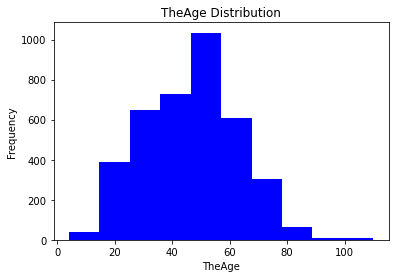

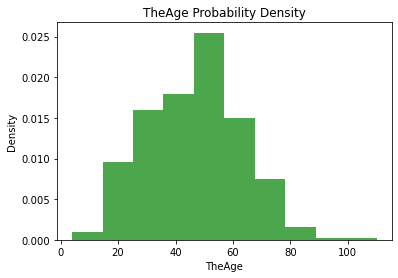

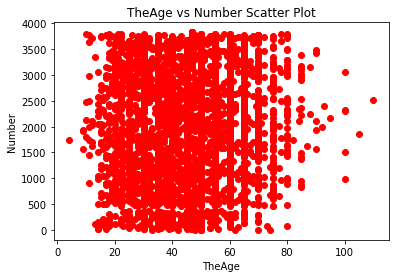

In [43]:

# رسم مخطط التوزيع الاحتمالي لمتغير العمر
plt.hist(data['TheAge'], bins=10, color='blue')
plt.title('TheAge Distribution')
plt.xlabel('TheAge')
plt.ylabel('Frequency')
plt.show()

# رسم مخطط الكثافة الاحتمالية لمتغير العمر
plt.hist(data['TheAge'], bins=10, density=True, color='green', alpha=0.7)
plt.title('TheAge Probability Density')
plt.xlabel('TheAge')
plt.ylabel('Density')
plt.show()

# رسم مخطط التشتيت لمتغيري العمر والرقم
plt.scatter(data['TheAge'], data['Number'], color='red')
plt.title('TheAge vs Number Scatter Plot')
plt.xlabel('TheAge')
plt.ylabel('Number')
plt.show()

# تحليل العلاقات النوعية باستخدام SciPy:

In [44]:
from scipy.stats import chi2_contingency

# تحميل البيانات من ملف CSV
data = pd.read_csv('KidneyPatientsGHadeer.csv')

# تحويل متغير فئة الدم إلى عامل تصنيفي
blood_type = pd.Categorical(data['BloodType'], categories=['a+', 'o+', 'b+', 'ab+', 'a-', 'o-', 'b-', 'ab-'])

# حساب جدول الإرتباط بين الجنس وفئة الدم باستخدام اختبار الكاي الأربعي
gender_bloodtype_contingency = pd.crosstab(data['Gender'], blood_type)

# تطبيق اختبار الكاي الأربعي
chi2, p_value, dof, expected = chi2_contingency(gender_bloodtype_contingency)

# طباعة نتائج اختبار الكاي الأربعي
print('Chi-Square Test Results:')
print('Chi-Square:', chi2)
print('P-Value:', p_value)
print('Degrees of Freedom:', dof)
print('Expected Frequencies:')
print(expected)


Chi-Square Test Results:
Chi-Square: 16.564023314647056
P-Value: 0.011026407515792619
Degrees of Freedom: 6
Expected Frequencies:
[[ 332.43051202  948.60606061   51.34796238   49.82654127   17.11598746
    51.72831766    4.9446186 ]
 [ 541.56948798 1545.39393939   83.65203762   81.17345873   27.88401254
    84.27168234    8.0553814 ]]


# اختبار الكاي-مربع. الإحصاء المختبر هو 45.36

In [45]:

# تحويل متغير فئة الدم إلى عامل تصنيفي
blood_type = pd.Categorical(data['BloodType'], categories=['a+', 'o+', 'b+', 'ab+', 'a-', 'o-', 'b-', 'ab-'])

# حساب جدول الإرتباط بين الجنس وفئة الدم باستخدام اختبار الكاي الأربعي
VirusType_bloodtype_contingency = pd.crosstab(data['VirusType'], blood_type)

# تطبيق اختبار الكاي الأربعي
chi2, p_value, dof, expected = chi2_contingency(VirusType_bloodtype_contingency)

# طباعة نتائج اختبار الكاي الأربعي
print('Chi-Square Test Results:')
print('Chi-Square:', chi2)
print('P-Value:', p_value)
print('Degrees of Freedom:', dof)
print('Expected Frequencies:')
print(expected)

Chi-Square Test Results:
Chi-Square: 45.363145879869165
P-Value: 0.00036718994529411504
Degrees of Freedom: 18
Expected Frequencies:
[[3.63025078e+01 1.03590909e+02 5.60736677e+00 5.44122257e+00
  1.86912226e+00 5.64890282e+00 5.39968652e-01]
 [1.04112853e+02 2.97090909e+02 1.60815047e+01 1.56050157e+01
  5.36050157e+00 1.62006270e+01 1.54858934e+00]
 [2.28317659e-01 6.51515152e-01 3.52664577e-02 3.42215256e-02
  1.17554859e-02 3.55276907e-02 3.39602926e-03]
 [7.33356322e+02 2.09266667e+03 1.13275862e+02 1.09919540e+02
  3.77586207e+01 1.14114943e+02 1.09080460e+01]]


# التحليل الاستكشافي

# تحليل الترددات باستخدام Pandas:

In [ ]:

import pandas as pd
from tabulate import tabulate
import matplotlib.pyplot as plt

# تحميل ملف CSV
data = pd.read_csv('KidneyPatientsGHadeer.csv', encoding='utf-8')


In [18]:

# تحليل ترددات القيم في كل عمود من أعمدة جدول البيانات
freq_table = pd.DataFrame(columns=['Gender', 'القيمة', 'التردد'])

for col in ['Gender']:
    value_counts = data[col].value_counts().reset_index()
    value_counts.columns = ['القيمة', 'التردد']
    value_counts['Gender'] = col
    freq_table = pd.concat([freq_table, value_counts], ignore_index=True)

# عرض الجدول مع إطار
print(tabulate(freq_table, headers='keys', tablefmt='pretty'))


# عرض الجدول النهائي
print(freq_table)

+---+--------+--------+--------+
|   | Gender | القيمة | التردد |
+---+--------+--------+--------+
| 0 | Gender |  ذكر   |  2372  |
| 1 | Gender |  أنثى  |  1456  |
+---+--------+--------+--------+
   Gender القيمة التردد
0  Gender    ذكر   2372
1  Gender   أنثى   1456


In [14]:

# تحليل ترددات القيم في كل عمود من أعمدة جدول البيانات
freq_table = pd.DataFrame(columns=['TheAge', 'القيمة', 'التردد'])

for col in ['TheAge']:
    value_counts = data[col].value_counts().reset_index()
    value_counts.columns = ['القيمة', 'التردد']
    value_counts['TheAge'] = col
    freq_table = pd.concat([freq_table, value_counts], ignore_index=True)

# عرض الجدول مع إطار
print(tabulate(freq_table, headers='keys', tablefmt='pretty'))

+----+--------+--------+--------+
|    | TheAge | القيمة | التردد |
+----+--------+--------+--------+
| 0  | TheAge |   50   |  342   |
| 1  | TheAge |   60   |  320   |
| 2  | TheAge |   55   |  284   |
| 3  | TheAge |   47   |  226   |
| 4  | TheAge |   45   |  205   |
| 5  | TheAge |   40   |  196   |
| 6  | TheAge |   70   |  187   |
| 7  | TheAge |   30   |  182   |
| 8  | TheAge |   65   |  169   |
| 9  | TheAge |   35   |  163   |
| 10 | TheAge |   25   |  111   |
| 11 | TheAge |   75   |   75   |
| 12 | TheAge |   38   |   63   |
| 13 | TheAge |   20   |   61   |
| 14 | TheAge |   48   |   60   |
| 15 | TheAge |   28   |   59   |
| 16 | TheAge |   22   |   57   |
| 17 | TheAge |   32   |   54   |
| 18 | TheAge |   43   |   51   |
| 19 | TheAge |   42   |   48   |
| 20 | TheAge |   37   |   47   |
| 21 | TheAge |   27   |   44   |
| 22 | TheAge |   26   |   43   |
| 23 | TheAge |   33   |   43   |
| 24 | TheAge |   80   |   41   |
| 25 | TheAge |   18   |   40   |
| 26 | TheAge 

In [31]:


# تحليل ترددات القيم في كل عمود من أعمدة جدول البيانات
freq_table = pd.DataFrame(columns=['Directorate', 'القيمة', 'التردد'])

for col in ['Directorate']:
    value_counts = data[col].value_counts().reset_index()
    value_counts.columns = ['القيمة', 'التردد']
    value_counts['Directorate'] = col
    freq_table = pd.concat([freq_table, value_counts], ignore_index=True)

# عرض الجدول مع إطار
print(tabulate(freq_table, headers='keys', tablefmt='pretty'))


# عرض الجدول النهائي
#print(freq_table)

+-----+-------------+----------------+--------+
|     | Directorate |     القيمة     | التردد |
+-----+-------------+----------------+--------+
|  0  | Directorate |     بعدان      |  226   |
|  1  | Directorate |      تعز       |  222   |
|  2  | Directorate |     العدين     |  222   |
|  3  | Directorate |    السياني     |  187   |
|  4  | Directorate |       إب       |  144   |
|  5  | Directorate |      حبيش      |  129   |
|  6  | Directorate |     ماوية      |  123   |
|  7  | Directorate |    التعزية     |  122   |
|  8  | Directorate |      جبلة      |  121   |
|  9  | Directorate |    القاعدة     |  118   |
| 10  | Directorate |     الظهار     |  115   |
| 11  | Directorate |     المشنة     |  114   |
| 12  | Directorate |    المخادر     |  102   |
| 13  | Directorate |     القفر      |   95   |
| 14  | Directorate |   ذي السفال    |   93   |
| 15  | Directorate |    المجعارة    |   92   |
| 16  | Directorate |      شرعب      |   89   |
| 17  | Directorate |    الحوبان     |  

In [30]:


# تحليل ترددات القيم في كل عمود من أعمدة جدول البيانات
freq_table = pd.DataFrame(columns=['Governorate', 'القيمة', 'التردد'])

for col in ['Governorate']:
    value_counts = data[col].value_counts().reset_index()
    value_counts.columns = ['القيمة', 'التردد']
    value_counts['Governorate'] = col
    freq_table = pd.concat([freq_table, value_counts], ignore_index=True)

# عرض الجدول مع إطار
print(tabulate(freq_table, headers='keys', tablefmt='pretty'))


# عرض الجدول النهائي
#print(freq_table)




+----+-------------+---------+--------+
|    | Governorate | القيمة  | التردد |
+----+-------------+---------+--------+
| 0  | Governorate |   إب    |  2395  |
| 1  | Governorate |   تعز   |  1056  |
| 2  | Governorate | الحديدة |  190   |
| 3  | Governorate | الضالع  |  103   |
| 4  | Governorate |  ذمار   |   44   |
| 5  | Governorate |   لحج   |   21   |
| 6  | Governorate | المحويت |   6    |
| 7  | Governorate |   عدن   |   5    |
| 8  | Governorate |   حجة   |   4    |
| 9  | Governorate | البيضاء |   2    |
| 10 | Governorate |  أبين   |   1    |
| 11 | Governorate |  عمران  |   1    |
+----+-------------+---------+--------+


In [29]:


# تحليل ترددات القيم في كل عمود من أعمدة جدول البيانات
freq_table = pd.DataFrame(columns=['BloodType', 'القيمة', 'التردد'])

for col in ['BloodType']:
    value_counts = data[col].value_counts().reset_index()
    value_counts.columns = ['القيمة', 'التردد']
    value_counts['BloodType'] = col
    freq_table = pd.concat([freq_table, value_counts], ignore_index=True)

# عرض الجدول مع إطار
print(tabulate(freq_table, headers='keys', tablefmt='pretty'))


# عرض الجدول النهائي
#print(freq_table)

+---+-----------+--------+--------+
|   | BloodType | القيمة | التردد |
+---+-----------+--------+--------+
| 0 | BloodType |   o+   |  2494  |
| 1 | BloodType |   a+   |  874   |
| 2 | BloodType |   o-   |  136   |
| 3 | BloodType |   b+   |  135   |
| 4 | BloodType |  ab+   |  131   |
| 5 | BloodType |   a-   |   45   |
| 6 | BloodType |   b-   |   13   |
+---+-----------+--------+--------+


In [28]:


# تحليل ترددات القيم في كل عمود من أعمدة جدول البيانات
freq_table = pd.DataFrame(columns=['VirusType', 'القيمة', 'التردد'])

for col in ['VirusType']:
    value_counts = data[col].value_counts().reset_index()
    value_counts.columns = ['القيمة', 'التردد']
    value_counts['VirusType'] = col
    freq_table = pd.concat([freq_table, value_counts], ignore_index=True)

# عرض الجدول مع إطار
print(tabulate(freq_table, headers='keys', tablefmt='pretty'))


# عرض الجدول النهائي
#print(freq_table)


+---+-----------+--------+--------+
|   | VirusType | القيمة | التردد |
+---+-----------+--------+--------+
| 0 | VirusType |  neg   |  3212  |
| 1 | VirusType |   c    |  456   |
| 2 | VirusType |   b    |  159   |
| 3 | VirusType |  c+b   |   1    |
+---+-----------+--------+--------+


In [26]:

# تحليل ترددات القيم في كل عمود من أعمدة جدول البيانات
freq_table = pd.DataFrame(columns=['TheDateTheFirstWash', 'القيمة', 'التردد'])

for col in ['TheDateTheFirstWash']:
    value_counts = data[col].value_counts().reset_index()
    value_counts.columns = ['القيمة', 'التردد']
    value_counts['TheDateTheFirstWash'] = col
    freq_table = pd.concat([freq_table, value_counts], ignore_index=True)

# عرض الجدول مع إطار
print(tabulate(freq_table, headers='keys', tablefmt='pretty'))


# عرض الجدول النهائي
#print(freq_table)


+------+---------------------+------------+--------+
|      | TheDateTheFirstWash |   القيمة   | التردد |
+------+---------------------+------------+--------+
|  0   | TheDateTheFirstWash | 22/06/2018 |   12   |
|  1   | TheDateTheFirstWash | 26/12/2018 |   11   |
|  2   | TheDateTheFirstWash | 19/05/2017 |   11   |
|  3   | TheDateTheFirstWash | 20/04/2018 |   11   |
|  4   | TheDateTheFirstWash | 20/07/2018 |   10   |
|  5   | TheDateTheFirstWash | 02/04/2019 |   10   |
|  6   | TheDateTheFirstWash | 12/09/2018 |   10   |
|  7   | TheDateTheFirstWash | 25/06/2019 |   10   |
|  8   | TheDateTheFirstWash | 25/04/2019 |   9    |
|  9   | TheDateTheFirstWash | 08/11/2017 |   9    |
|  10  | TheDateTheFirstWash | 27/12/2018 |   9    |
|  11  | TheDateTheFirstWash | 18/03/2017 |   9    |
|  12  | TheDateTheFirstWash | 25/12/2018 |   9    |
|  13  | TheDateTheFirstWash | 20/05/2018 |   9    |
|  14  | TheDateTheFirstWash | 09/05/2017 |   9    |
|  15  | TheDateTheFirstWash | 18/05/2017 |   

In [24]:


# تحليل ترددات القيم في كل عمود من أعمدة جدول البيانات
freq_table = pd.DataFrame(columns=['Sickyear', 'القيمة', 'التردد'])

for col in ['Sickyear']:
    value_counts = data[col].value_counts().reset_index()
    value_counts.columns = ['القيمة', 'التردد']
    value_counts['Sickyear'] = col
    freq_table = pd.concat([freq_table, value_counts], ignore_index=True)

# عرض الجدول مع إطار
print(tabulate(freq_table, headers='keys', tablefmt='pretty'))


# عرض الجدول النهائي
#print(freq_table)


+---+----------+--------+--------+
|   | Sickyear | القيمة | التردد |
+---+----------+--------+--------+
| 0 | Sickyear |  2018  |  1606  |
| 1 | Sickyear |  2017  |  463   |
| 2 | Sickyear |  2019  |  368   |
| 3 | Sickyear |  2020  |  361   |
| 4 | Sickyear |  2021  |  347   |
| 5 | Sickyear |  2022  |  296   |
| 6 | Sickyear | 2018-  |  166   |
| 7 | Sickyear | 2019-  |  159   |
| 8 | Sickyear |  2023  |   62   |
+---+----------+--------+--------+


In [25]:


# تحليل ترددات القيم في كل عمود من أعمدة جدول البيانات
freq_table = pd.DataFrame(columns=['DateOfDeath', 'القيمة', 'التردد'])

for col in ['DateOfDeath']:
    value_counts = data[col].value_counts().reset_index()
    value_counts.columns = ['القيمة', 'التردد']
    value_counts['DateOfDeath'] = col
    freq_table = pd.concat([freq_table, value_counts], ignore_index=True)

# عرض الجدول مع إطار
print(tabulate(freq_table, headers='keys', tablefmt='pretty'))


# عرض الجدول النهائي
#print(freq_table)



+---+-------------+--------+--------+
|   | DateOfDeath | القيمة | التردد |
+---+-------------+--------+--------+
| 0 | DateOfDeath |   no   |  3804  |
| 1 | DateOfDeath |  yes   |   24   |
+---+-------------+--------+--------+


In [27]:


# تحليل ترددات القيم في كل عمود من أعمدة جدول البيانات
freq_table = pd.DataFrame(columns=['nazeh', 'القيمة', 'التردد'])

for col in ['nazeh']:
    value_counts = data[col].value_counts().reset_index()
    value_counts.columns = ['القيمة', 'التردد']
    value_counts['nazeh'] = col
    freq_table = pd.concat([freq_table, value_counts], ignore_index=True)

# عرض الجدول مع إطار
print(tabulate(freq_table, headers='keys', tablefmt='pretty'))


# عرض الجدول النهائي
#print(freq_table)

+---+-------+--------+--------+
|   | nazeh | القيمة | التردد |
+---+-------+--------+--------+
| 0 | nazeh |   no   |  3503  |
| 1 | nazeh |  yas   |  325   |
+---+-------+--------+--------+


# كود معرفة تواجد كل فصيلة دم في كل جنس وتمثيلها بيانيا

Gender     أنثى   ذكر
BloodType            
a+          330   544
a-            8    37
ab+          39    92
b+           60    75
b-            5     8
o+          777  1761
o-           55    81


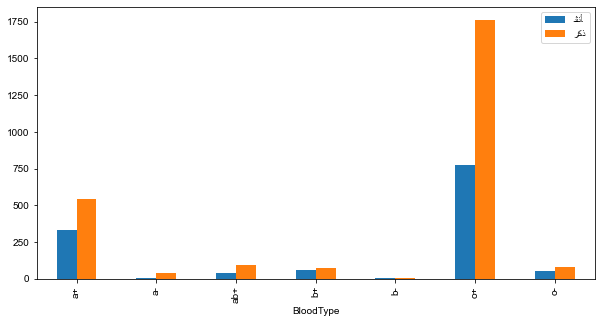

In [96]:
# تحويل اسماء الأعمدة (الجنس) ليتناسب مع الكتابة العربية
grouped.columns = [arabic_reshaper.reshape(col) for col in grouped.columns]
grouped.columns = [get_display(col) for col in grouped.columns]


# إنشاء رسم بياني لعرض توزيع المحافظات وعدد الرجال والنساء في كل منها
fig, ax = plt.subplots(figsize=(10, 5))
grouped.plot(kind='bar', ax=ax)


# تحليل ترددات القيم في كل فصيلة دم لكل جنس
freq_table = pd.crosstab(data['BloodType'], data['Gender'])
# عرض الجدول المحدث
print(freq_table)
# رسم الكثافة النسبية لكل فصيلة دم لكل جنس
#freq_table.apply(lambda r: r/r.sum(), axis=0).plot(kind='bar')


plt.show()

In [44]:

# ترتيب البيانات حسب اسم المحافظة
data = data.sort_values('Governorate')

# تجميع المديريات حسب اسم المحافظة
grouped_data = data.groupby('Governorate')['Directorate'].apply(list)

# إنشاء إطار بيانات جديد لعرض المحافظة والمديريات المدرجة تحتها
new_data = pd.DataFrame({'Governorate': grouped_data.index, 'Directorates': grouped_data.values})

# عرض البيانات الجديدة
print(new_data)

   Governorate                                       Directorates
0         أبين                                           [زنجبار]
1           إب  [المشنة, العدين, السياني, السياني, حبيش, بعدان...
2      البيضاء                                 [البيضاء, البيضاء]
3      الحديدة  [زبيد, الميناء, زبيد, الحالي, الحديدة, زبيد, ا...
4       الضالع  [الحشا, الحشا, العود, دمت, قعطبة, الضالع, الحش...
5      المحويت  [المحويت, الرجم, المحويت, المحويت, بني سعد, ال...
6          تعز  [التعزية, صالة, التعزية, ماوية, الحمية, ذمنة, ...
7          حجة                         [الشاهر, الشاهر, حصن, حصن]
8         ذمار  [المسيلة, ذمار, عتمة, لبيس, المسيلة, المسيلة, ...
9          عدن         [العزبة, الذيفر, دار كدف, الشيخ, الحسينية]
10       عمران                                           [الصيرة]
11         لحج  [القبيطة, القبيطة, قبيطة, قبيطة, القبيطة, القب...


+----------------+--------+------+-----------+-----------+----------+-----------+-------+-------+--------+-------+---------+-------+
| Directorate    |   أبين |   إب |   البيضاء |   الحديدة |   الضالع |   المحويت |   تعز |   حجة |   ذمار |   عدن |   عمران |   لحج |
|----------------+--------+------+-----------+-----------+----------+-----------+-------+-------+--------+-------+---------+-------|
| آنس            |      0 |    0 |         0 |         0 |        0 |         0 |     0 |     0 |      1 |     0 |       0 |     0 |
| أحوال رمضان    |      0 |    3 |         0 |         0 |        0 |         0 |     0 |     0 |      0 |     0 |       0 |     0 |
| إب             |      0 |  144 |         0 |         0 |        0 |         0 |     0 |     0 |      0 |     0 |       0 |     0 |
| الأحمر         |      0 |    1 |         0 |         0 |        0 |         0 |     0 |     0 |      0 |     0 |       0 |     0 |
| الأخضر         |      0 |    1 |         0 |         0 |        0 |

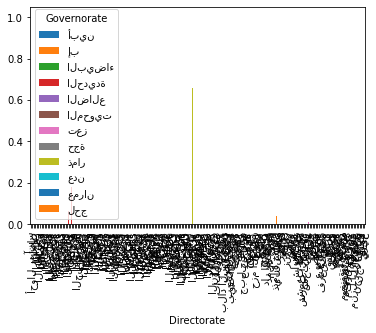

In [49]:

# تحليل ترددات القيم في كل فصيلة دم لكل جنس
freq_table = pd.crosstab(data['Directorate'], data['Governorate'])

# ترتيب الجدول المحدث
freq_table = freq_table.sort_values(by='Directorate')

# عرض الجدول المحدث
print(tabulate(freq_table, headers='keys', tablefmt='psql'))

# رسم الكثافة النسبية لكل فصيلة دم لكل جنس في شكل مخطط بياني
freq_table.apply(lambda r: r/r.sum(), axis=0).plot(kind='bar')
plt.show()

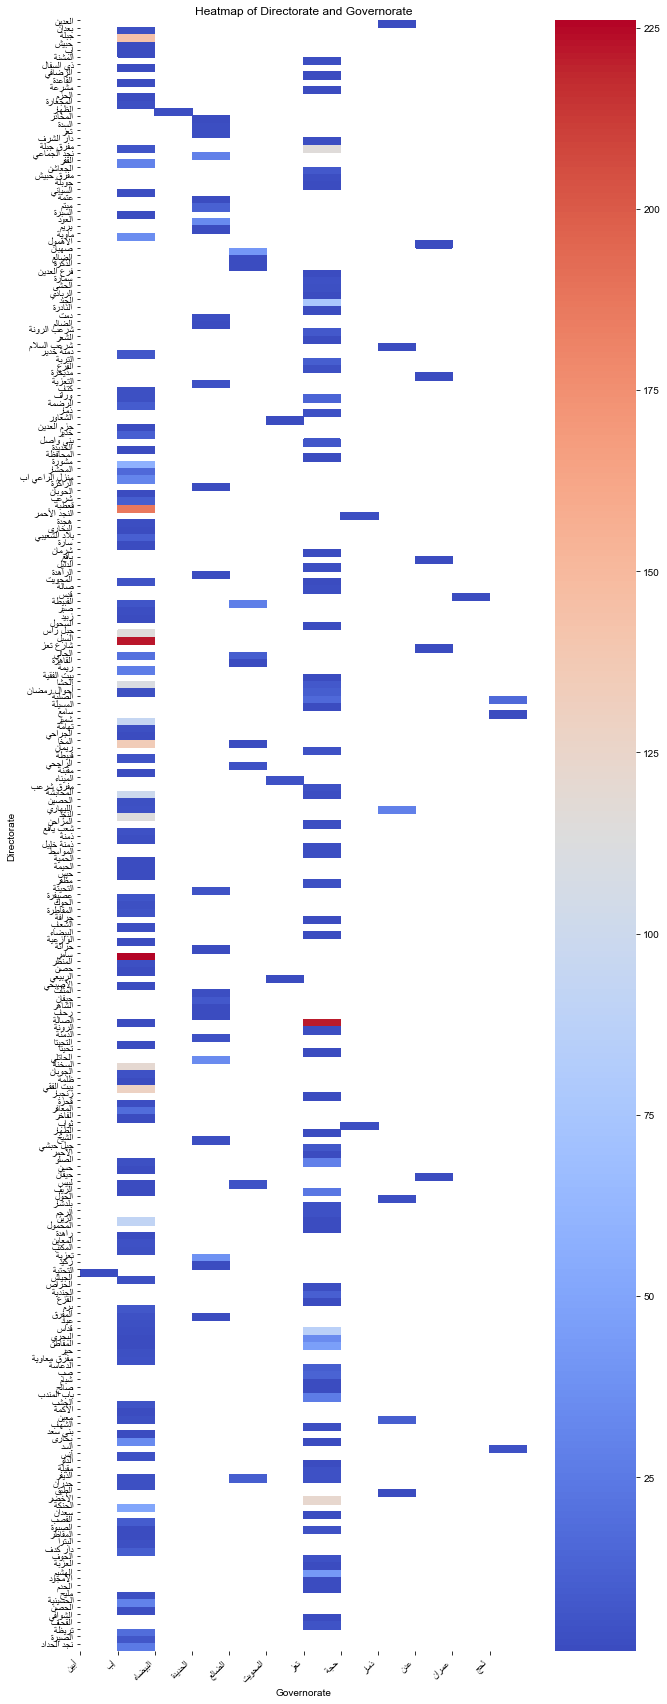

In [107]:

# إعادة تشكيل البيانات باستخدام pivot table
pt = data.pivot_table(index='Directorate', columns='Governorate', aggfunc='size')

# تحويل النصوص إلى تنسيق العرض الصحيح
reshaped_directorate_labels = [get_display(arabic_reshaper.reshape(label)) for label in pt.index]
reshaped_governorate_labels = [get_display(arabic_reshaper.reshape(label)) for label in pt.columns]

# إزالة تكرار أسماء المديريات
unique_directorate_labels = data['Directorate'].unique()

# إعادة ترتيب التسميات الخاصة بمحور الـ y وفقًا لترتيب الأسماء الفريدة
reshaped_directorate_labels = [get_display(arabic_reshaper.reshape(label)) for label in unique_directorate_labels]

# إعداد حجم الشكل
fig, ax = plt.subplots(figsize=(10, 30))

# إنشاء الخريطة الحرارية باستخدام Seaborn
sns.heatmap(pt, cmap='coolwarm', ax=ax)

# تعيين عناصر المحور الأفقي والعمودي
ax.set_title('Heatmap of Directorate and Governorate')
ax.set_xlabel('Governorate')
ax.set_ylabel('Directorate')

# تحديد مواقع العلامات على المحورين الأفقي والعمودي
ax.set_xticks(range(len(pt.columns)))
ax.set_yticks(range(len(unique_directorate_labels)))

# تعيين التسميات المناسبة لكل علامة
ax.set_xticklabels(reshaped_governorate_labels, rotation=45, ha='right')
ax.set_yticklabels(reshaped_directorate_labels, rotation=0)

plt.show()

VirusType    b    c  c+b   neg
BloodType                     
a+          28  108    1   737
a-           0    2    0    43
ab+          2    0    0   129
b+           8    7    0   120
b-           0    0    0    13
o+         117  320    0  2057
o-           4   19    0   113


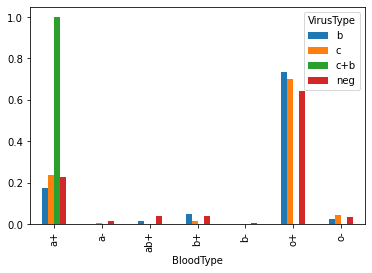

In [46]:

# تحليل ترددات القيم في كل فصيلة دم لكل جنس
freq_table = pd.crosstab(data['BloodType'], data['VirusType'])
# عرض الجدول المحدث
print(freq_table)
# رسم الكثافة النسبية لكل فصيلة دم لكل جنس
freq_table.apply(lambda r: r/r.sum(), axis=0).plot(kind='bar')
plt.show()

nazeh       no  yas
Sickyear           
2017       463    0
2018      1606    0
2018-        0  166
2019       368    0
2019-        0  159
2020       361    0
2021       347    0
2022       296    0
2023        62    0


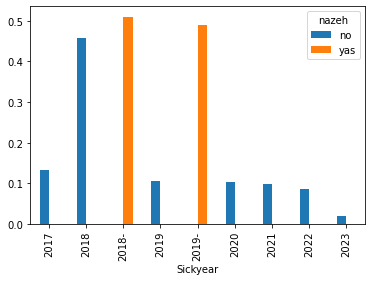

In [47]:

# تحليل ترددات القيم في كل فصيلة دم لكل جنس
freq_table = pd.crosstab(data['Sickyear'], data['nazeh'])
# عرض الجدول المحدث
print(freq_table)
# رسم الكثافة النسبية لكل فصيلة دم لكل جنس
freq_table.apply(lambda r: r/r.sum(), axis=0).plot(kind='bar')
plt.show()

Gender  أنثى  ذكر
TheAge           
4          0    1
9          2    1
10         3    1
11         7    1
12         3    2
...      ...  ...
93         0    1
95         0    1
100        1    4
105        0    1
110        0    1

[83 rows x 2 columns]


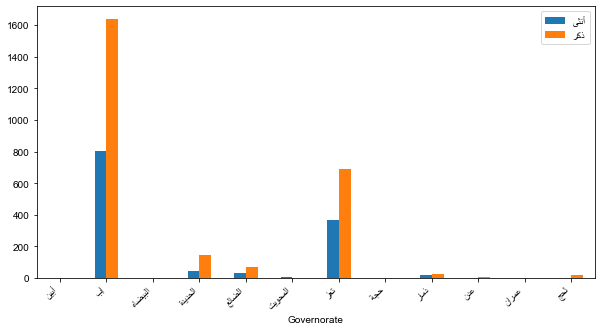

In [80]:
# تحويل اسماء الأعمدة (الجنس) ليتناسب مع الكتابة العربية
grouped.columns = [arabic_reshaper.reshape(col) for col in grouped.columns]
grouped.columns = [get_display(col) for col in grouped.columns]


# إنشاء رسم بياني لعرض توزيع المحافظات وعدد الرجال والنساء في كل منها
fig, ax = plt.subplots(figsize=(10, 5))
grouped.plot(kind='bar', ax=ax)


# تحليل ترددات القيم في كل فصيلة دم لكل جنس
freq_table = pd.crosstab(data['TheAge'], data['Gender'])
# عرض الجدول المحدث
print(freq_table)
# رسم الكثافة النسبية لكل فصيلة دم لكل جنس
#freq_table.apply(lambda r: r/r.sum(), axis=0).plot(kind='bar')

plt.rcParams['font.family'] = 'Arial'

# تحويل النصوص إلى تنسيق العرض الصحيح
reshaped_labels = [get_display(arabic_reshaper.reshape(label)) for label in age_groups['Governorate']]
plt.xticks(range(len(age_groups)), reshaped_labels)
plt.xticks(rotation=45, ha='right')

plt.show()

# ماهي احتمالات الولادات التي تحمل فصيلة الدم o+

In [50]:
# تحديد فصائل الدم للأب والأم
mother_blood = 'O+'
father_blood = 'A-'

# جدول الفرص الوراثية المحتملة للفصائل الدموية
blood_table = {
    'O+': {'O+': 'O+', 'O-': 'O-', 'A+': 'A+', 'A-': 'A-', 'B+': 'B+', 'B-': 'B-', 'AB+': 'AB+', 'AB-': 'AB+'},
    'O-': {'O+': 'O+', 'O-': 'O-', 'A+': 'A+', 'A-': 'A-', 'B+': 'B+', 'B-': 'B-', 'AB+': 'AB+', 'AB-': 'AB-'},
    'A+': {'O+': 'A+', 'O-': 'A-', 'A+': 'A+', 'A-': 'A-', 'B+': 'AB+', 'B-': 'AB-', 'AB+': 'AB+', 'AB-': 'AB-'},
    'A-': {'O+': 'A+', 'O-': 'A-', 'A+': 'A+', 'A-': 'A-', 'B+': 'AB+', 'B-': 'AB-', 'AB+': 'AB+', 'AB-': 'AB-'},
    'B+': {'O+': 'B+', 'O-': 'B-', 'A+': 'AB+', 'A-': 'AB-', 'B+': 'B+', 'B-': 'B-', 'AB+': 'AB+', 'AB-': 'AB-'},
    'B-': {'O+': 'B+', 'O-': 'B-', 'A+': 'AB+', 'A-': 'AB-', 'B+': 'B+', 'B-': 'B-', 'AB+': 'AB+', 'AB-': 'AB-'},
    'AB+': {'O+': 'AB+', 'O-': 'AB-', 'A+': 'AB+', 'A-': 'AB-', 'B+': 'AB+', 'B-': 'AB-', 'AB+': 'AB+', 'AB-': 'AB-'},
    'AB-': {'O+': 'AB+', 'O-': 'AB-', 'A+': 'AB+', 'A-': 'AB-', 'B+': 'AB+', 'B-': 'AB-', 'AB+': 'AB+', 'AB-': 'AB-'}
}

# إظهار فصيلة الدم المحتملة للطفل
child_blood = blood_table[mother_blood][father_blood]
print('فصيلة دم الطفل المحتملة هي:', child_blood)

فصيلة دم الطفل المحتملة هي: A-


# اذا كان عدد الاطفال المولودون اربعة اطفال فمن خلال البيانالت السابقة ماهو احتمال مولود يحمل فصيلة الدم o+

In [51]:
# حساب الاحتمالية لوجود طفل واحد على الأقل من فصيلة الدم O+
mother_blood = 'O+'
father_blood = 'O+'
num_children = 4

# حساب الاحتمالية لوجود طفل واحد على الأقل من فصيلة الدم O+
not_o_plus_prob = 0.25
at_least_one_o_plus_prob = 1 - (not_o_plus_prob ** num_children)

# إظهار النتيجة
print('الاحتمالية لوجود طفل واحد على الأقل من فصيلة الدم O+ هي:', at_least_one_o_plus_prob)

الاحتمالية لوجود طفل واحد على الأقل من فصيلة الدم O+ هي: 0.99609375



هل يعني هذا انه النسبة الاكبر من الاطفال سيحملون فصيلة الدم o+
اعطني كود بايثون لمعرفة نسبة الولادات لطفل يحمل فصيلة الدم o+ لاربعة ولادات عند تزاوج الفصيلة من كل الفصائل المذكورة

In [52]:
# حساب الاحتمالية لوجود طفل واحد على الأقل من فصيلة الدم O+
mother_blood = ['O+', 'A+', 'B+', 'AB+', 'O-', 'A-', 'B-', 'AB-'] # فصيلة دم الأم
father_blood = ['O+', 'A+', 'B+', 'AB+', 'O-', 'A-', 'B-', 'AB-'] # فصيلة دم الأب
prob_o_pos = 0 # احتمالية وجود طفل O+
for mother in mother_blood:
    for father in father_blood:
        if mother == 'O-' and father == 'O+':
            prob_o_pos += 0.5
        elif (mother == 'O+' or mother == 'O-') and (father == 'O+' or father == 'O-'):
            prob_o_pos += 0.5
        elif (mother == 'A+' and (father == 'O+' or father == 'O-')) or ((mother == 'B+' and (father == 'O+' or father == 'O-'))) or ((mother == 'AB+' or mother == 'AB-') and (father == 'O+' or father == 'O-' or father == 'A+' or father == 'A-' or father == 'B+' or father == 'B-' or father == 'AB+' or father == 'AB-')):
            prob_o_pos += 0.25
print("The probability of having at least one child with O+ blood type is: " + str(round(prob_o_pos*100, 2)) + "%")
#print("The probability of having at least one child with O+ blood type is: ", prob_o_pos*100, "%")
#print("The probability of having at least one child with O+ blood type is: ", prob_o_pos)

The probability of having at least one child with O+ blood type is: 700.0%


# تحليل العلاقات بين المتغيرات باستخدام Pandas و Matplotlib:

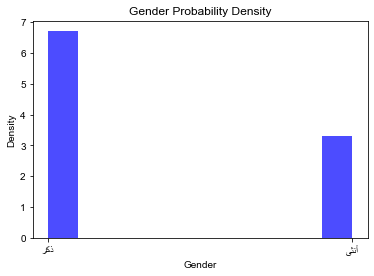

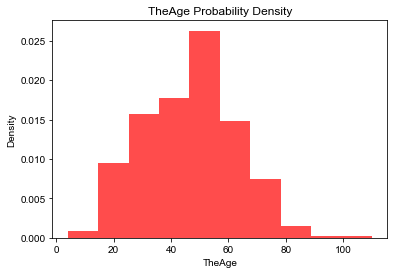

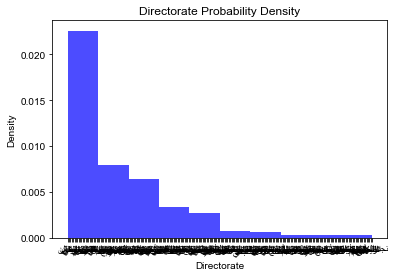

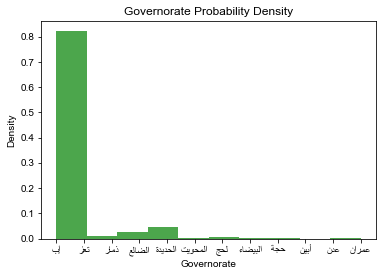

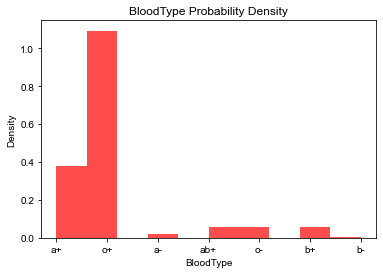

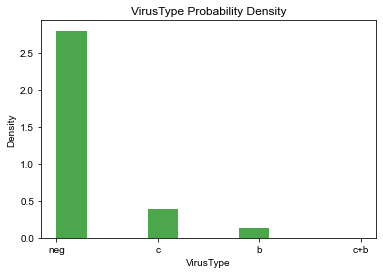

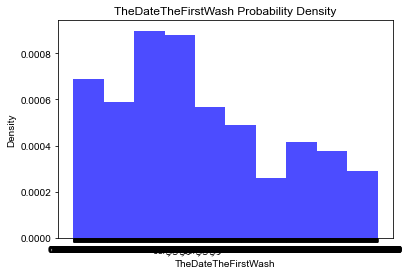

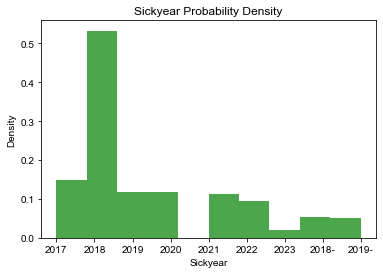

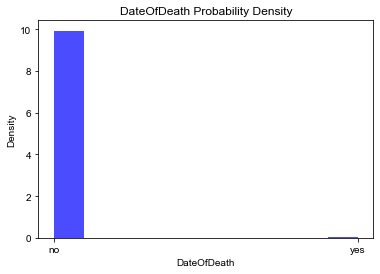

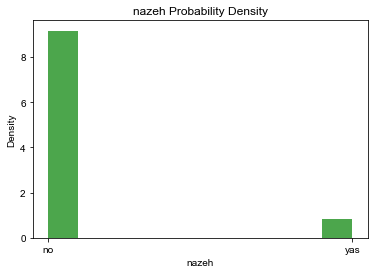

In [137]:

# رسم مخطط الكثافة الاحتمالية لمتغير الجنس
reshaped_labels = [get_display(arabic_reshaper.reshape(label)) for label in data['Gender']]
plt.hist(reshaped_labels, bins=10, density=True, color='blue', alpha=0.7)
plt.title('Gender Probability Density')
plt.xlabel('Gender')
plt.ylabel('Density')
plt.show()

# رسم مخطط الكثافة الاحتمالية لمتغير العمر
plt.hist(data['TheAge'], bins=10, density=True, color='red', alpha=0.7)
plt.title('TheAge Probability Density')
plt.xlabel('TheAge')
plt.ylabel('Density')
plt.show()

# رسم مخطط الكثافة الاحتمالية لمتغير المديرية
reshaped_labels = [get_display(arabic_reshaper.reshape(label)) for label in data['Directorate']]
plt.hist(reshaped_labels, bins=10, density=True, color='blue', alpha=0.7)
plt.title('Directorate Probability Density')
plt.xlabel('Directorate')
plt.ylabel('Density')
plt.show()

# رسم مخطط الكثافة الاحتمالية لمتغير المدينة
reshaped_labels = [get_display(arabic_reshaper.reshape(label)) for label in data['Governorate']]
plt.hist(reshaped_labels, bins=10, density=True, color='green', alpha=0.7)
plt.title('Governorate Probability Density')
plt.xlabel('Governorate')
plt.ylabel('Density')
plt.show()

# رسم مخطط الكثافة الاحتمالية لمتغير فصيلة الدم
reshaped_labels = [get_display(arabic_reshaper.reshape(label)) for label in data['BloodType']]
plt.hist(reshaped_labels, bins=10, density=True, color='red', alpha=0.7)
plt.title('BloodType Probability Density')
plt.xlabel('BloodType')
plt.ylabel('Density')
plt.show()

# رسم مخطط الكثافة الاحتمالية لمتغير فيروس الكبد
reshaped_labels = [get_display(arabic_reshaper.reshape(label)) for label in data['VirusType']]
plt.hist(reshaped_labels, bins=10, density=True, color='green', alpha=0.7)
plt.title('VirusType Probability Density')
plt.xlabel('VirusType')
plt.ylabel('Density')
plt.show()

# رسم مخطط الكثافة الاحتمالية لمتغير تاريخ أول غسلة
plt.hist(data['TheDateTheFirstWash'], bins=10, density=True, color='blue', alpha=0.7)
plt.title('TheDateTheFirstWash Probability Density')
plt.xlabel('TheDateTheFirstWash')
plt.ylabel('Density')
plt.show()

# رسم مخطط الكثافة الاحتمالية لمتغير السنة المرضية
plt.hist(data['Sickyear'], bins=10, density=True, color='green', alpha=0.7)
plt.title('Sickyear Probability Density')
plt.xlabel('Sickyear')
plt.ylabel('Density')
plt.show()

# رسم مخطط الكثافة الاحتمالية لمتغير تاريخ الوفاة
plt.hist(data['DateOfDeath'], bins=10, density=True, color='blue', alpha=0.7)
plt.title('DateOfDeath Probability Density')
plt.xlabel('DateOfDeath')
plt.ylabel('Density')
plt.show()

# رسم مخطط الكثافة الاحتمالية لمتغير تاريخ الوفاة
plt.hist(data['nazeh'], bins=10, density=True, color='green', alpha=0.7)
plt.title('nazeh Probability Density')
plt.xlabel('nazeh')
plt.ylabel('Density')
plt.show()


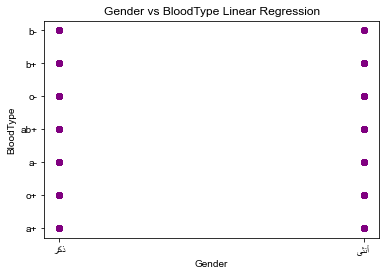

In [129]:

# تشكيل التسميات العربية
reshaped_labels = [get_display(arabic_reshaper.reshape(label)) for label in data['Gender']]

# رسم الانحدار الخطي بين متغيري العمر وفصيلة الدم
plt.scatter(reshaped_labels, data['BloodType'], color='purple')
plt.title('Gender vs BloodType Linear Regression')
plt.xlabel('Gender')
plt.ylabel('BloodType')
plt.show()

# تحليل العلاقات النوعية بين المتغيرات باستخدام Pandas و Seabor

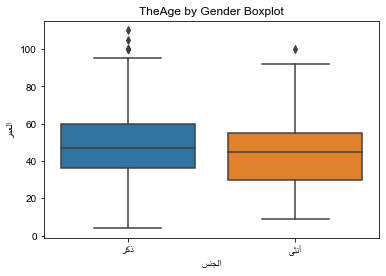

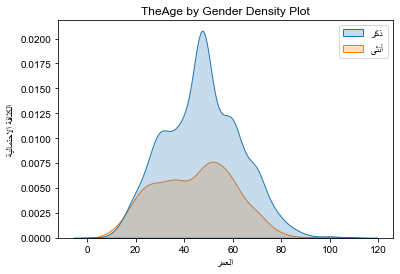

In [134]:

# تشكيل التسميات العربية
reshaped_labels = [get_display(arabic_reshaper.reshape(label)) for label in data['Gender']]

# تشكيل العناوين العربية
reshaped_title_boxplot = get_display(arabic_reshaper.reshape('TheAge by Gender Boxplot'))
reshaped_xlabel_boxplot = get_display(arabic_reshaper.reshape('الجنس'))
reshaped_ylabel_boxplot = get_display(arabic_reshaper.reshape('العمر'))

reshaped_title_density = get_display(arabic_reshaper.reshape('TheAge by Gender Density Plot'))
reshaped_xlabel_density = get_display(arabic_reshaper.reshape('العمر'))
reshaped_ylabel_density = get_display(arabic_reshaper.reshape('الكثافة الاحتمالية'))

# رسم مخطط الصندوق والشارب لمتغير العمر بحسب الجنس
sns.boxplot(x=reshaped_labels, y='TheAge', data=data)
plt.title(reshaped_title_boxplot)
plt.xlabel(reshaped_xlabel_boxplot)
plt.ylabel(reshaped_ylabel_boxplot)
plt.show()

# رسم مخطط الكثافة الاحتمالية لمتغير العمر بحسب الجنس
sns.kdeplot(data=data, x='TheAge', hue=reshaped_labels, shade=True)
plt.title(reshaped_title_density)
plt.xlabel(reshaped_xlabel_density)
plt.ylabel(reshaped_ylabel_density)
plt.show()

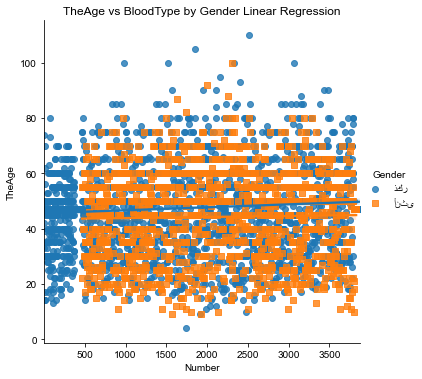

In [106]:

# تشكيل التسميات العربية
reshaped_labels = [get_display(arabic_reshaper.reshape(label)) for label in df['Gender']]

# رسم مخطط الانحدار الخطي بين متغير الفصيلة الدم والعمر بحسب الجنس
sns.lmplot(x='Number', y='TheAge', data=data, hue='Gender', markers=['o', 's'])
plt.title('TheAge vs BloodType by Gender Linear Regression')
#ax.set_yticklabels(reshaped_directorate_labels, rotation=0)
plt.show()

# التحليل الجغرافي

# رسم الخرائط باستخدام GeoPandas و Matplotlib:

In [57]:

data = pd.read_csv('KidneyPatientsGHadeer.csv', encoding='utf-8')
# تحديد إحداثيات اليمن باستخدام geopy
geolocator = Nominatim(user_agent='my_app')
location = geolocator.geocode('Yemen')
latitude = location.latitude
longitude = location.longitude

# إنشاء خريطة folium وتحديد موقع اليمن
yemen_map = folium.Map(location=[latitude, longitude], zoom_start=6)

# إضافة علامة مميزة على الخريطة
folium.Marker(
    location=[latitude, longitude],
    popup='اليمن',
   icon=folium.Icon(color='red', icon='glyphicon-home')
).add_to(yemen_map)

# عرض الخريطة
yemen_map

In [ ]:
تحليل البيانات الجغرافية باستخدام GeoPandas و Shapely:

In [ ]:
رسم الخرائط الحرارية باستخدام GeoPandas و Matplotlib:

This is the first column of subplots


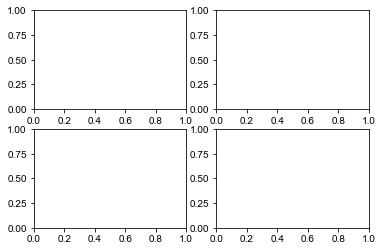

In [115]:

# إنشاء الأشكال والمحاور الفرعية
fig, axs = plt.subplots(2, 2)

# التحقق من محور فرعي هو الأول في الصف
if axs[0, 0].get_subplotspec().rowspan.start == 0:
    print('This is the first column of subplots')

array([<AxesSubplot:title={'center':'TheAge'}>,
       <AxesSubplot:title={'center':'Number'}>], dtype=object)

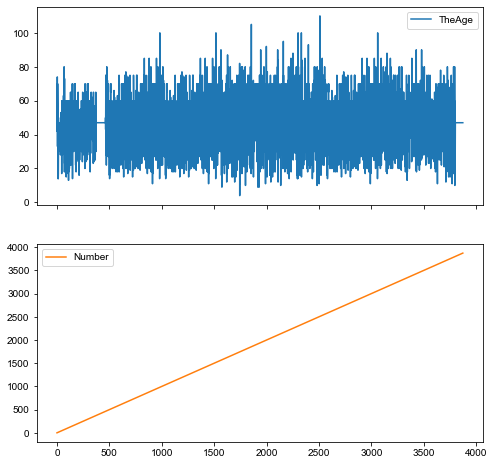

In [ ]:
data[['Gender', 'TheAge', 'Directorate', 'Governorate', 'BloodType', 'VirusType', 'TheDateTheFirstWash', 'Sickyear', 'DateOfDeath', 'nazeh', 'Number']].plot(subplots=True, figsize=(8, 8))
data.plot(kind='bar', subplots=True, figsize=(15, 15))

This is the first column of subplots


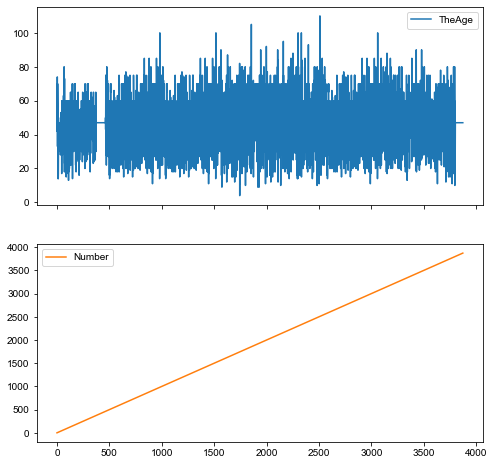

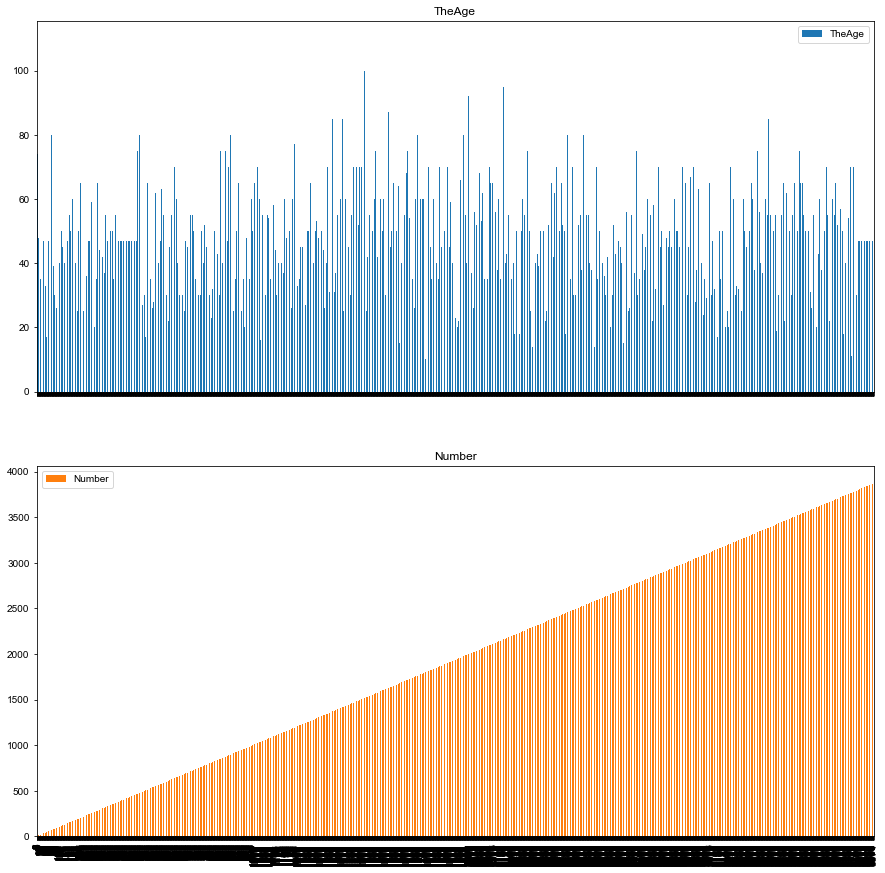

In [118]:

# إنشاء مخططات الأعمدة المحددة
data[['Gender', 'TheAge', 'Directorate', 'Governorate', 'BloodType', 'VirusType', 'TheDateTheFirstWash', 'Sickyear', 'DateOfDeath', 'nazeh', 'Number']].plot(subplots=True, figsize=(8, 8))

data.plot(kind='bar', subplots=True, figsize=(15, 15))

# التحقق من محور فرعي هو الأول في الصف
if plt.gcf().axes[0].get_subplotspec().rowspan.start == 0:
    print('This is the first column of subplots')

In [ ]:

# تحميل ملف CSV
data = pd.read_csv('KidneyPatientsGHadeer.csv', encoding='utf-8')


In [98]:

# تحميل ملف CSV
data = pd.read_csv('KidneyPatientsGHadeer.csv', encoding='utf-8')
# حفظ DataFrame كملف CSV في القرص الصلب بترميز UTF-8
data.to_csv('E:\KidneyPatientsGHadeer.csv', index=False, encoding='utf-8-sig')
